In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ranksums
from scipy.ndimage import uniform_filter1d
import openpyxl

In [8]:
file = '/Users/k_anisha/Downloads/S1Dataset.XLSX'

succ = pd.read_excel(file, sheet_name = 'successful, temp').to_numpy().T
fail_pre = pd.read_excel(file, sheet_name = 'failed, temp, pre').to_numpy().T
fail_post = pd.read_excel(file, sheet_name = 'failed, temp, post').to_numpy().T

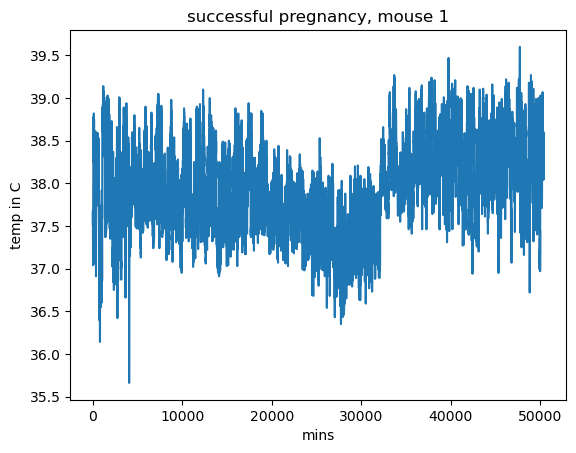

In [12]:
# first we can take a look at the raw data 

plt.plot(succ[0])
plt.title('successful pregnancy, mouse 1')
plt.ylabel('temp in C')
plt.xlabel('mins')
plt.show()

In [13]:
# find the difference between the max and min temperature per each tmie window
def temp_range(data, start, end):
    return np.max(data[:, start:end], axis = 1) - np.min(data[:, start:end], axis = 1)

In [14]:
# we can look at one day of change... 1 day = 24 hr x 60 min = 1440 min
succ_range = temp_range(succ, 0, 1440)
fail_pre_range = temp_range(fail_pre, 0, 1440)
fail_post_range = temp_range(fail_post, 0, 1440)

In [ ]:
# is temperature variability different between preg and non preg mice?
#  
stat, p = ranksums(succ_range, fail_post_range)
print('p-value', p)

p-value 0.00021985068263840363


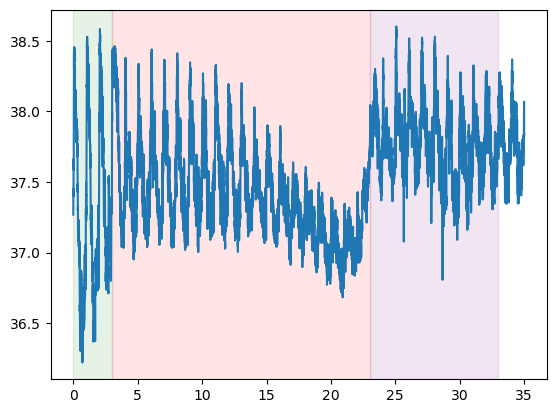

In [ ]:
 # find the number of days
t = np.arange(len(succ[0])) / 1440

plt.plot(t, np.mean(succ, axis=0))
g0 = 3  
preg_end = g0 + 20
birth = preg_end + 10

plt.axvspan(0, g0, alpha=0.1, color="green", label="estrous")
plt.axvspan(g0, preg_end, alpha=0.1, color="red", label="pregnancy")
plt.axvspan(preg_end, birth, alpha=0.1, color="purple", label="lactation")

In [ ]:
# what the matlab code is doing:
    # loads temperature data from pregnant and non-pregnant mice
    # compares CBT before and after pairing, to see if it changes
    # turns the raw temperature data into distributions
        # histograms of how much time is spent at each temperature
    # finally, tests whether the distsributions differ (success vs failure pregnancy prediction)
        # basically testing if they come from the same distribution